![logo](./figures/LogoLine_horizon_C3S.png)

# Monthly Standardised Precipitation-Evapotranspiration Index (SPEI) for 6 months cumulation period

This Jupyter Notebook illustrates how to calculate the index **spei6** (Monthly Standardised Precipitation-Evapotranspiration Index for a 6-Month Accumulation period). Here the CMIP6-ACCESS_CM2 mode is used as an example.

For a quick demonstration, the calculation is performed over a specific region (Spain) for the ssp585 experiment (2015-2100).

First, monthly potential evapotranspiration (pet) and precipitation (r) CMIP6 data is downloaded from the ["Gridded dataset underpinning the Copernicus Interactive Climate Atlas"](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview) (an example for pet calculation is availiable on the following notebook [pet.ipynb](https://github.com/ecmwf-projects/c3s-atlas/blob/main/book/notebooks/pet.ipynb)). Then SPEI6 is calculated and compared with the ["Gridded dataset underpinning the Copernicus Interactive Climate Atlas"](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview). Note that the SPEI6 and SPI6 are standardised indices that use a reference period for their standardisation. Therefore, to reproduce exactly the same results available in the [C3S Atlas reference dataset](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview) the same reference period (1971-2005) is used.

An additional notebook, [wetdry_conditions.ipynb](https://github.com/ecmwf-projects/c3s-atlas/blob/main/book/notebooks/wetdry_conditions.ipynb), illustrates the challenges of estimating drought events in a climate change context and shows how to calculate the wet and dry condition analysis included in the C3S Atlas.

In [1]:
import xclim
import cdsapi
import os 
from pathlib import Path
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import xarray as xr
import inspect

from xclim.indices import (
    standardized_precipitation_evapotranspiration_index,
)
from c3s_atlas.utils import (
    extract_zip_and_delete
)

## Download climate data with the CDS API

To reduce data size and download time, a geographical subset focusing on Spain is selected.

- Catalogue: [Gridded dataset underpinning the Copernicus Interactive Climate Atlas](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview)

> ⚠️ **Warning: Exposed API Credentials**
>
> For security reasons, it is not recommended to hardcode your Copernicus Climate Data Store (CDS) API credentials in notebooks.
>
> Instead, store them securely in a `.cdsapirc` file in your home directory.
>
> 📄 More info: [CDS API - How to use the API](https://cds.climate.copernicus.eu/how-to-api)

In [2]:
cdsapi_url = "https://cds.climate.copernicus.eu/api"
cdsapi_key = ""

In [3]:
c = cdsapi.Client(url = cdsapi_url, key=cdsapi_key)

Running the code blocks bellow will download the data from the CDS as specified by the following API keywords:

**Project:** `C3S Atlas dataset`\
**Origin:** `CMIP6`\
**Variables:** `Monthly mean of daily Accumulated Potential Evapotranspiration; Monthly mean Precipitation; Monthly Standardised Precipitation Evapotranspiration Index for 6 months cumulation period`  
**Experiment:** `SSP5-8.5`  
**Year:** `1950-2014; 2015-2100`  
**Area:** `[44.5, -9.5, 35.5, 3.5]` (Cropped over Spain)

In [5]:
# Download CMIP6 data for the calculation of SPEI6 with historical reference period of calibration and future projection
file_dest_c3satlas = Path('./data/c3s-atlas')
os.makedirs(file_dest_c3satlas, exist_ok=True)
experiment_periods = {
    "historical": "1850-2014",
    "ssp5_8_5": "2015-2100",
}
variables_c3s= {
    "pet": "monthly_daily_accumulated_potential_evapotranspiration",
    "r": "monthly_precipitation",
    "spei6": "monthly_standardised_precipitation_evapotranspiration_index_for_6_months_cumulation_period",
}

In [ ]:
catalogue_id = "multi-origin-c3s-atlas"
for experiment in experiment_periods.keys():
    period=experiment_periods[experiment]
    for var in variables_c3s.keys():
        path_zip = file_dest_c3satlas / f"c3s-atlas-CMIP6_monthly_{var}_{experiment}_{period}.zip"
        request = {

            "origin": "cmip6",
            "experiment": experiment,
            "domain": "global",
            "period": period,
            "variable": variables_c3s[var],
            'area': [44.5, -9.5, 35.5, 3.5],
        }
        print(f"Launching request {request} and saving to {path_zip}")
        c.retrieve(catalogue_id, request, path_zip)
        extract_zip_and_delete(path_zip)

### Load the data in a dictionary selecting ACCESS-CM2 model



In [6]:
ds_pet_ssp = xr.open_dataset(file_dest_c3satlas / "c3s-atlas-CMIP6_monthly_pet_ssp5_8_5_2015-2100.nc")
ds_r_ssp = xr.open_dataset(file_dest_c3satlas / "c3s-atlas-CMIP6_monthly_r_ssp5_8_5_2015-2100.nc")
ds_spei6_ssp = xr.open_dataset(file_dest_c3satlas / "c3s-atlas-CMIP6_monthly_spei6_ssp5_8_5_2015-2100.nc")
ds_pet_hist = xr.open_dataset(file_dest_c3satlas / "c3s-atlas-CMIP6_monthly_pet_historical_1850-2014.nc")
ds_r_hist = xr.open_dataset(file_dest_c3satlas / "c3s-atlas-CMIP6_monthly_r_historical_1850-2014.nc")
ds_spei6_hist = xr.open_dataset(file_dest_c3satlas / "c3s-atlas-CMIP6_monthly_spei6_historical_1850-2014.nc")

In [7]:
# select a specific member of the ensemble
select_member = [
    str(mem.data) for mem in ds_pet_ssp.member_id if "access" in str(mem.data).lower()
][0]

In [8]:
ds_pet_ssp_member = ds_pet_ssp.sel(member=np.where(ds_pet_ssp.member_id.values == select_member)[0]).squeeze(drop=True)
ds_r_ssp_member = ds_r_ssp.sel(member=np.where(ds_r_ssp.member_id.values == select_member)[0]).squeeze(drop=True)
ds_spei6_ssp_member = ds_spei6_ssp.sel(member=np.where(ds_spei6_ssp.member_id.values == select_member)[0]).squeeze(drop=True)
ds_pet_hist_member = ds_pet_hist.sel(member=np.where(ds_pet_hist.member_id.values == select_member)[0]).squeeze(drop=True)
ds_r_hist_member = ds_r_hist.sel(member=np.where(ds_r_hist.member_id.values == select_member)[0]).squeeze(drop=True)
ds_spei6_hist_member = ds_spei6_hist.sel(member=np.where(ds_spei6_hist.member_id.values == select_member)[0]).squeeze(drop=True)

## Calculation of WB (Water Budget) 
The water balance (WB), also referred to as the water budget, represents the difference between the amount of water entering and leaving a system. It is calculated as:

**WB = Precipitation (r) − Potential Evapotranspiration (pet)**

The water balance is required to calculate **SPEI6**, as it accounts for both precipitation (**r**) and potential evapotranspiration (**pet**), capturing the effects of temperature and global warming on drought conditions.  
In contrast, **SPI6** only relies on precipitation (**r**) and does not consider changes in evapotranspiration, making it less sensitive to climate warming impacts.

The water budget is computed using PET estimated with the Hargreaves–Samani (1985) method (see [pet.ipynb](https://github.com/ecmwf-projects/c3s-atlas/blob/main/book/notebooks/pet.ipynb)), together with precipitation data from the ["Gridded dataset underpinning the Copernicus Interactive Climate Atlas"](https://cds.climate.copernicus.eu/datasets/multi-origin-c3s-atlas?tab=overview).

Precipitation (r) and pet from both the historical and SSP simulations are concatenated to produce a continuous water budget time series for the full period 1850–2100.

In [ ]:
# Concatenate historical and ssp data in a single ds
ds_r_member = xr.concat([ds_r_hist_member, ds_r_ssp_member], dim = 'time')
ds_pet_member = xr.concat([ds_pet_hist_member, ds_pet_ssp_member], dim = 'time')

In [10]:
ds_wb_member = ds_r_member["r"] - ds_pet_member["pet"]
ds_wb_member = ds_wb_member.to_dataset(name = 'wb')
ds_wb_member['wb'].attrs['units'] = 'mm/day'

## Calculation of SPEI6 index 

The SPEI6 index is computed using the WB. The calculation is performed with the function implemented in [xclim](https://xclim.readthedocs.io/en/stable/_modules/xclim/indices/_agro.html#standardized_precipitation_evapotranspiration_index). For calculation of the standard SPEI6, the reference period used is "1971-01-01/2005-12-31". The window parameter is 6 month for spei6, the distribution recommended is fisk and the fitting method recommended is maximum likelihood. The water budget calculated from the pet and r monthly data is also in a monthly frequency and the spei6 resulted does not need to be aggregated monthly as the result of the xclim function is also provided at the same temporal aggregation.

**Important**: Note that depending on the xclim versions used, the spei6 results can differ when comparing them with the C3S Atlas datasets, since there have been some improvements in the latest versions of xclim. To exactly reproduce the results currently available in version v2.5 of the dataset, the xclim version used is: xclim=0.47.0=py38h578d9bd_0.

In [28]:
def calculate_spei6(wb, freq, cal_start="1971-01-01", cal_end="2005-12-31"):
    """Calculate spei6."""

    offset = abs(np.nanmin(wb.values))
    if offset == 0:
        offset = "0.0001 mm day-1"
    else:
        offset = f"{offset} mm day-1"

    wb.attrs["units"] = "mm day-1"

    # Check if offset parameter exists in this xclim version
    sig = inspect.signature(standardized_precipitation_evapotranspiration_index)

    kwargs = dict(
        wb=wb,
        cal_start=cal_start,
        cal_end=cal_end,
        freq=freq,
        window=6,
        dist="fisk",
        method="ML",
    )

    if "offset" in sig.parameters:
        kwargs["offset"] = offset
    else:
        wb = wb + abs(np.nanmin(wb.values))

    dataset_f = standardized_precipitation_evapotranspiration_index(**kwargs)

    dataset_f = dataset_f.to_dataset(name="spei6")

    return dataset_f

In [ ]:
ds_spei6_member_calculated = calculate_spei6(ds_wb_member['wb'], "MS", cal_start = "1971-01-01", cal_end = "2005-12-31")

### Plot results SPEI6

Comparison of the results obtained with present Jupyter notebook and the reference C3S Atlas Dataset underpinning the C3S Atlas. A timeseries of a specific point on the center of Spain is selected to show the results. The figure shows that the results obtained with this notebook and from the C3S Atlas datasets are identical, and therefore fully reproducible.

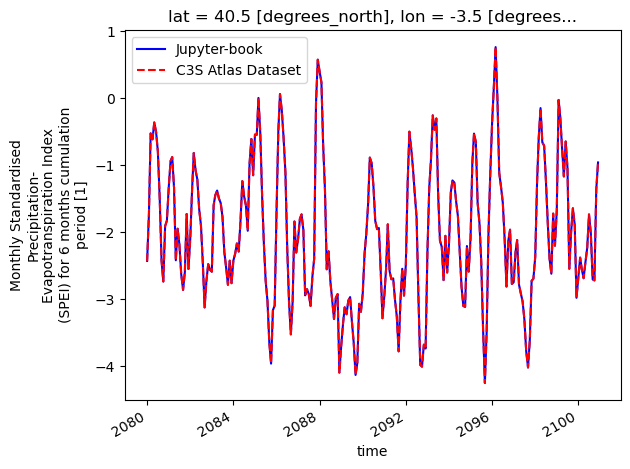

In [13]:
latitud = 40.0
longitud = -3.5
ds_spei6_member_calculated['spei6'].sel(lat=latitud, lon=longitud, method="nearest").sel(time=slice("2080-01-01", "2100-12-31")).plot(linestyle = '-', color = 'b',label='Jupyter-book')
ds_spei6_ssp_member['spei6'].sel(lat=latitud, lon=longitud, method="nearest").sel(time=slice("2080-01-01", "2100-12-31")).plot(linestyle = '--', color = 'r',label='C3S Atlas Dataset')
plt.legend()

### Loading and applying the barrean_mask to the calculated SPEI6 index
A bare-earth (barrean) mask is necessary for Standardized Precipitation Index (SPI) and Standardized Precipitation Evapotranspiration Index (SPEI) calculations to ensure meaningful results in arid or non-vegetated regions. More information and recipes for calculating the Barrean mask can be in found the [auxiliar](https://github.com/ecmwf-projects/c3s-atlas/blob/main/auxiliar/barrean_mask.ipynb) folder of the c3s-atlas repository.

In [28]:
barrean_ds = xr.open_dataset("../../auxiliar/reference-grids/barrean_mask_CMIP6.nc")
# Select the spatial subset
barrean_ds = barrean_ds.sel(
    lat = slice(ds_spei6_member_calculated.lat.min(), ds_spei6_member_calculated.lat.max()),
    lon = slice(ds_spei6_member_calculated.lon.min(), ds_spei6_member_calculated.lon.max())
)
# Apply the mask
ds_spei6_member_calculated['spei6'] = xr.where(barrean_ds["barrean"] == 1, ds_spei6_member_calculated['spei6'], np.nan)

## Compare the results with the "Gridded dataset underpinning the Copernicus Interactive Climate Atlas"

Comparison of the results obtained with present Jupyter notebook and the reference C3S Atlas Dataset underpinning the C3S Atlas. A geographical subset focusing on Spain is selected to show the results. The figure shows that the results obtained with this notebook and from the C3S Atlas datasets are identical, and therefore fully reproducible.

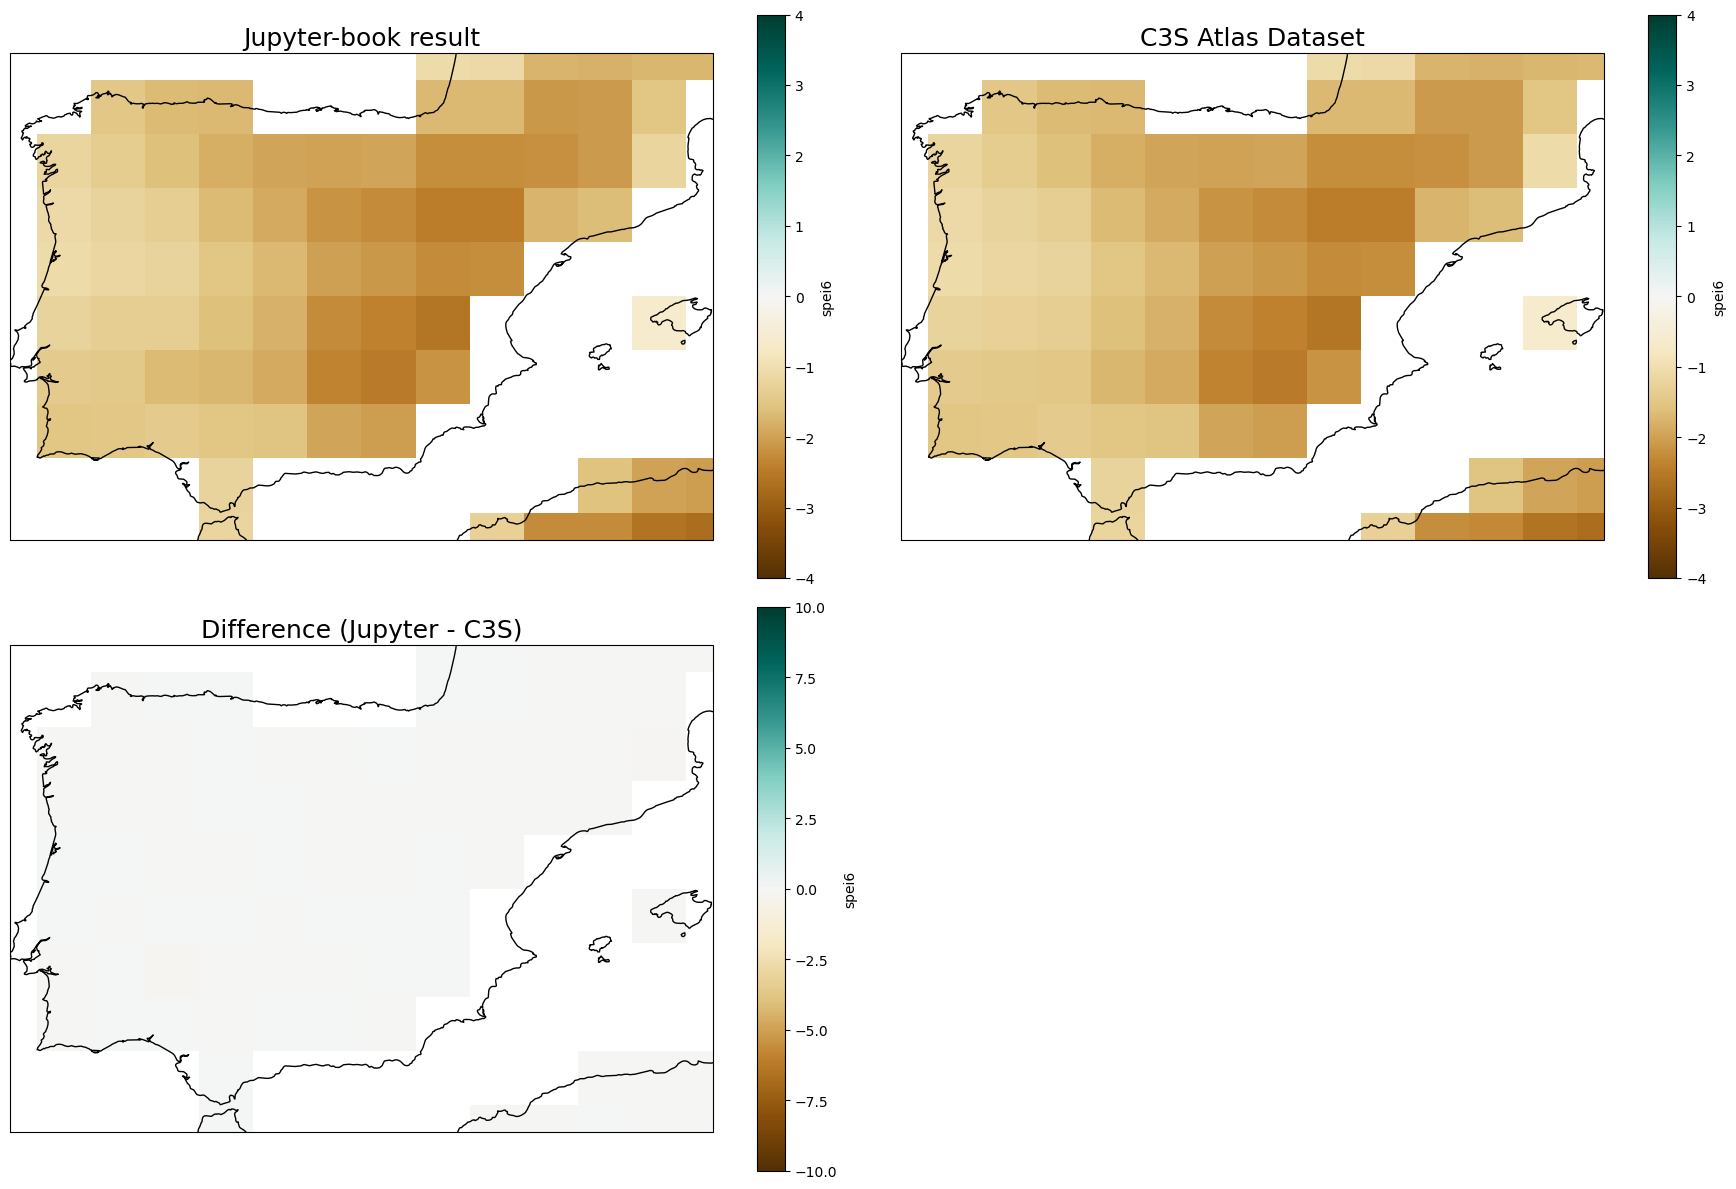

In [42]:
zoomin_extent = [-9.5, 3.5, 35.5, 44.5]
title_size = 18

proj = ccrs.PlateCarree()
fig, ax = plt.subplots(
    nrows=2, ncols=2,
    subplot_kw={'projection': proj},
    figsize=(18, 12)
)

# calculate the difference
diff = ds_spei6_member_calculated - ds_spei6_ssp_member

ds_spei6_member_calculated["spei6"].sel(time=slice("2080-01-01", "2100-12-31")).mean(dim='time').plot(ax = ax[0, 0], cmap = 'BrBG', vmin = -4, vmax = 4)
ax[0, 0].set_title('Jupyter-book result', fontsize = title_size)
ax[0, 0].set_extent(zoomin_extent)
ax[0, 0].coastlines()

ds_spei6_ssp_member["spei6"].sel(time=slice("2080-01-01", "2100-12-31")).mean(dim='time').plot(ax = ax[0, 1], cmap = 'BrBG', vmin = -4, vmax = 4)
ax[0, 1].set_title('C3S Atlas Dataset', fontsize = title_size)
ax[0, 1].set_extent(zoomin_extent)
ax[0, 1].coastlines()

diff["spei6"].sel(time=slice("2080-01-01", "2100-12-31")).mean(dim='time').plot(ax=ax[1, 0], cmap="BrBG", vmin=-10, vmax=10)
ax[1, 0].set_title("Difference (Jupyter - C3S)", fontsize = title_size)
ax[1, 0].set_extent(zoomin_extent)
ax[1, 0].coastlines()

fig.delaxes(ax[1, 1])
plt.tight_layout()
plt.show()

The figure demonstrates that the results obtained with this notebook are identical to those from the C3S Atlas datasets, and are therefore fully reproducible.